In [1]:
import os
import yaml 
import gc
import matplotlib.pyplot as plt


In [2]:
from cccma_ppp.generic.distributed import Distributed
distributed= Distributed.get_instance()

# individually

## Test IO

In [3]:
from cccma_ppp.data.utils_data import ModelDataConfig, ObsDataConfig, ConditionDataConfig
from cccma_ppp.preprocessing.preprocessing import *


from cccma_ppp.preprocessing.utils_preprocessing import *
from cccma_ppp.data.datasets import *

In [4]:
from cccma_ppp.data.dataloader import *

In [5]:
expe_dir = Path("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test")
os.environ["GLOBAL_EXP_DIR"] = str(expe_dir)

os.environ["GLOBAL_CHECKPOINT_DIR"] = os.path.join(expe_dir, "training_checkpoints")
os.environ["GLOBAL_FIGURES_DIR"] = os.path.join(expe_dir, "figures")
os.environ["GLOBAL_LOG_DIR"] = os.path.join(expe_dir, "logs")

checkpoint_dir = os.path.join(expe_dir, "training_checkpoints")
figures_dir = os.path.join(expe_dir, "figures")
log_dir = os.path.join(expe_dir, "logs")

In [6]:
model_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data'
observation_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations'
input_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'anomalies') ,PreprocessingStepSelector(name = 'oceannanremover')])
target_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'standardizer'),PreprocessingStepSelector(name = 'oceannanremover')])
name = ['tas']

model = ModelDataConfig(paths = model_path, names = name, preprocessing_pipeline=input_pp, concat_dim='year')
observation = ObsDataConfig(paths = observation_path, names = name, preprocessing_pipeline=target_pp, concat_dim='year', rename_dict={'lead_time' : 'month'})

In [7]:
config_ds = XArrayDatasetConfig(model=model, observation= observation, time_features=['year'], condition_method='ensemble_mean')

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/data/datasets.py:48: UserWarning: model and observation data do not have the same latitudes cooridnates.
  warnings.warn(f'model and observation data do not have the same latitudes cooridnates.')
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/data/datasets.py:50: UserWarning: model and observation data do not have the same longitudes cooridnates.
  warnings.warn(f'model and observation data do not have the same longitudes cooridnates.')


#### test dataset config

In [ ]:
# config_ds.model.paths

In [ ]:
# config_ds.available_train_time


In [ ]:
# print('common time: ', config_ds.get_common_time)
# print('available train time: ', config_ds.available_train_time)

In [8]:
## test saving:
config_ds._fit_preprocessors(train_years = [1980,2000])
## test loading:
# config_ds._load_fitted_preprocessors(load_dir= '.')

In [ ]:
# config_ds.model.preprocessing_pipeline.get_preprocessors('anomalies').mean
# 

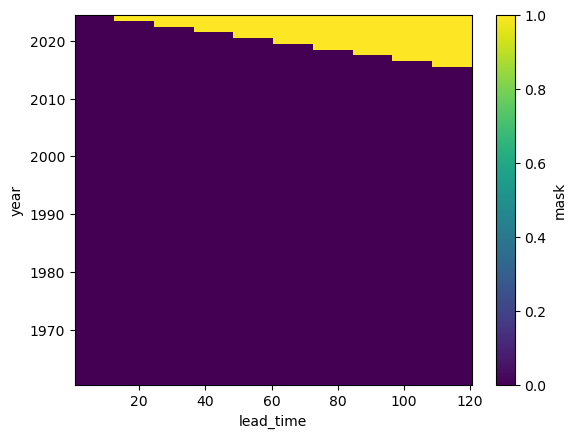

In [ ]:


# def _create_train_mask(years : list | xr.DataArray , lead_times: list | xr.DataArray |int , exclude_idx=0):

#     if isinstance(lead_times , int):
#         lead_times = np.arange(1, lead_times+1)

#     mask = np.full((len(years), len(lead_times)), False, dtype=bool)
#     x = np.arange(0, 12*mask.shape[0], 12)   
#     y = np.arange(1, mask.shape[1] + 1)
#     idx_array = x[..., None] + y
#     # mask[idx_array >= idx_array[-1, exclude_idx + 12]] = True
#     mask[idx_array > idx_array[-1, exclude_idx + 11]] = True

#     return xr.DataArray(
#         mask,
#         dims=('year', 'lead_time'),
#         coords={'year': years, 'lead_time': lead_times},
#         name="mask"
#     )

# mask = _create_train_mask(config_ds.available_train_time, config_ds.num_model_lead_months)
# mask.plot()

In [10]:
# config_ds.get_common_time

In [ ]:
# dataset = config_ds.build(years =[1980,2000] , mask = None, return_metadata = False)

In [ ]:
# dataset._autoencoding_input

False

In [ ]:
# dataset[0]['input'].shape

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/data/datasets.py:444: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1702400410390/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  added_features = torch.as_tensor(time_features, dtype=torch.float32)


torch.Size([1, 60, 120])

In [ ]:
# dataset.mask

In [ ]:
# dataset = config_ds.build(config_ds.available_train_time, mask = mask)

#### test dataloader config

In [9]:
trainlodaer_config = TrainDataloaderConfig(config_ds,train_years = [1980,1982], batch_size = 10, num_data_workers=0)

In [10]:
trainlodaer_config.setup_distributed(distributed)
train_loader = trainlodaer_config.build_train_loader(return_spatial_mask=False)

In [ ]:
# len(train_loader.dataset)

In [ ]:
# train_loader.dataset[0]

In [ ]:
# data = next(iter(train_loader))

In [ ]:
# train_loader.dataset.config.target_info.coords['lat'].size

## test losses

In [ ]:
from  cccma_ppp.loss.utils_loss import *
from  cccma_ppp.loss.loss import *


In [ ]:
loss_config = LosspipelineConfig(
    loss_pipeline = [ LossStepConfig(name = 'mse' , args =  {'low_ress_kernel_size':3})],
    reduction='sum'
    # loss_weights= [0.2,0.8] 
)

In [ ]:
weights = config_ds.get_weights()

In [ ]:
weights

In [ ]:
loss = loss_config.build(weights, num_output_dimensions=1)

In [ ]:
loss.pipeline

In [ ]:
loss.weights

## test optimizer

In [11]:
from  cccma_ppp.core.optimization import OptimizerConfig, LRSchedulerConfig 

In [12]:
scheculer_config = LRSchedulerConfig()
oprimConfig = OptimizerConfig(lr_scheduler_config  = scheculer_config)

In [ ]:
# oprimConfig

## test module selectors

In [11]:
from  cccma_ppp.core.selectors import *
from  cccma_ppp.core.deterministic_module import *
from  cccma_ppp.core.cVAE_module import *
from  cccma_ppp.models.mlp_models import *

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [12]:
model_conf = cVAEModelSelector(type = 'MLP' , args = {'encoder_hidden_dims' : [3000,3000,3000], 
                                                                'latent_size' : 10,
                                                                'decoder_hidden_dims': [3000,3000,3000, 5000],
                                                                'condition_embedding_dims' :  [3000,3000,10],
                                                                'condition_dependant_latent': True,
                                                                'condemb_to_decoder':  True,
                                                                'batch_normalization' : True,
                                                                'dropout_rate': 0.5,
                                                                'init_method' :  'xavier'})
                                                                                        

In [13]:
model_conf.args

{'encoder_hidden_dims': [3000, 3000, 3000],
 'latent_size': 10,
 'decoder_hidden_dims': [3000, 3000, 3000, 5000],
 'condition_embedding_dims': [3000, 3000, 10],
 'condition_dependant_latent': True,
 'condemb_to_decoder': True,
 'batch_normalization': True,
 'dropout_rate': 0.5,
 'init_method': 'xavier'}

In [14]:
flow_ = NormalizedFlowConfig([FlowSelector(type = 'RealNVP',
                                           args = { 'hidden_dim' : 5} ),
                                FlowSelector(type = 'MAF',
                                           args = { 'hidden_dim' : 5} )])

In [15]:
_config  = {'ModelConfig'  : model_conf, 
            'min_posterior_variance' :  2,
                'prior_flow_config' : flow_,
            'combined_CGCN_weight' :  0.1}

In [16]:
cVAE_config = ModuleSelector(type = 'cVAE',
                          config = _config)

In [17]:
cVAE_config

ModuleSelector(type='cVAE', config={'ModelConfig': cVAEModelSelector(type='MLP', args={'encoder_hidden_dims': [3000, 3000, 3000], 'latent_size': 10, 'decoder_hidden_dims': [3000, 3000, 3000, 5000], 'condition_embedding_dims': [3000, 3000, 10], 'condition_dependant_latent': False, 'condemb_to_decoder': True, 'batch_normalization': True, 'dropout_rate': 0.5, 'init_method': 'xavier'}, load_dir=None, freeze_weights=False), 'min_posterior_variance': 2, 'prior_flow_config': NormalizedFlowConfig(list_flows=[FlowSelector(type='RealNVP', args={'hidden_dim': 5}), FlowSelector(type='MAF', args={'hidden_dim': 5})], flow_sample_size=5000), 'combined_CGCN_weight': 0.1})

In [18]:
train_loader.input_shape

(7200,)

In [19]:
cVAE_ = cVAE_config.build_module(train_loader.input_shape,train_loader.target_shape, train_loader.added_features_dim)

In [20]:
train_loader.input_shape

(7200,)

In [27]:
cVAE_.state_dict()

OrderedDict([('model.embedding.0.weight',
              tensor([[ 0.0099,  0.0062,  0.0207,  ...,  0.0156,  0.0207,  0.0074],
                      [ 0.0102, -0.0239,  0.0049,  ...,  0.0226, -0.0211,  0.0120],
                      [ 0.0040, -0.0181, -0.0146,  ..., -0.0123,  0.0006, -0.0210],
                      ...,
                      [ 0.0174,  0.0104,  0.0099,  ...,  0.0075, -0.0190,  0.0012],
                      [-0.0184, -0.0145,  0.0218,  ...,  0.0214,  0.0086, -0.0167],
                      [ 0.0203,  0.0004, -0.0117,  ..., -0.0229,  0.0064, -0.0118]])),
             ('model.embedding.0.bias',
              tensor([0., 0., 0.,  ..., 0., 0., 0.])),
             ('model.embedding.3.weight',
              tensor([1., 1., 1.,  ..., 1., 1., 1.])),
             ('model.embedding.3.bias',
              tensor([0., 0., 0.,  ..., 0., 0., 0.])),
             ('model.embedding.3.running_mean',
              tensor([0., 0., 0.,  ..., 0., 0., 0.])),
             ('model.embedding.3.r

In [21]:
cVAE_.config

cVAEConfig(ModelConfig=cVAEModelSelector(type='MLP', args={'encoder_hidden_dims': [3000, 3000, 3000], 'latent_size': 10, 'decoder_hidden_dims': [3000, 3000, 3000, 5000], 'condition_embedding_dims': [3000, 3000, 10], 'condition_dependant_latent': False, 'condemb_to_decoder': True, 'batch_normalization': True, 'dropout_rate': 0.5, 'init_method': 'xavier'}, load_dir=None, freeze_weights=False), min_posterior_variance=2, prior_flow_config=NormalizedFlowConfig(list_flows=[FlowSelector(type='RealNVP', args={'hidden_dim': 5}), FlowSelector(type='MAF', args={'hidden_dim': 5})], flow_sample_size=5000), combined_CGCN_weight=0.1, load_dir=None)

In [22]:
cVAE_.init_loss_function(loss)

NameError: name 'loss' is not defined

In [ ]:
cVAE_  = cVAE_.to(distributed.device)

In [ ]:
optimizer = oprimConfig.build(module =cVAE_, num_batches=len(train_loader), total_epochs=1)

## trainer test

In [ ]:
from  cccma_ppp.core.trainer import *

In [ ]:

# for path in (checkpoint_dir , figures_dir,log_dir ):
#     if distributed.is_root():
#         os.makedirs(path, exist_ok=True)



In [ ]:
from  cccma_ppp.loss.kld import BetaAnnealing
beta = BetaAnnealing(beta = 0.001, num_epoch_to_warmup=10)

In [ ]:
trainer_conf = TrainerConfig(
    beta_finder = beta,
    earlystoppingbuffer = 10,
    gradient_accumulation_steps =2,
    mixed_precision = True )

In [ ]:
trainer = trainer_conf.build(train_data_loader=train_loader,
                             validation_data_loader=None,
                             optimization=optimizer,
                             module=cVAE_,
                             epochs = 3)

In [ ]:
trainer.setup_distributed(distributed=distributed,
                          logger = None, 
                          log_every_n_epochs = 2)

In [ ]:
trainer.train()

# train.py

In [15]:
def prepare_config(path: str) -> dict:
    """Get config and update with possible dotlist override."""
    with open(path) as f:
        data = yaml.safe_load(f)
    return data


In [16]:
yaml_config = '/home/rpg002/CCCma_PPP/train_config.yaml'
config_data = prepare_config(yaml_config)

In [20]:
config_data['train_loader']

{'dataset_config': {'model': {'paths': '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data',
   'names': ['tas'],
   'preprocessing_pipeline': {'preprocessors_list': [{'name': 'anomalies',
      'args': {'dims': ['year', 'lead_time']}},
     {'name': 'oceannanremover'}],
    'ensemble_mean': True,
    'concat_dim': 'year',
    'observation': {'paths': '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations',
     'names': ['tas'],
     'preprocessing_pipeline': {'preprocessors_list': [{'name': 'standardizer'},
       {'name': 'oceannanremover'}]},
     'concat_dim': 'year',
     'rename_dict': {'lead_time': 'month'}},
    'time_features': ['year'],
    'num_lead_months': 120}},
  'batch_size': 10,
  'train_years': [1980, 1982],
  'num_validation_years': 0,
  'num_data_workers': 0}}

In [ ]:
from  cccma_ppp.train.train_configs import *
import dacite

In [ ]:
config = dacite.from_dict(data_class=TrainConfig, data=config_data, config=dacite.Config(strict=True))


In [ ]:
config

In [ ]:
config.set_random_seed()

In [ ]:
from cccma_ppp.generic.logger import setup_logger


In [ ]:
    logger = setup_logger(name = 'training',
                          log_dir = config.log_dir )

In [ ]:
config.log_dir

In [ ]:
    if distributed.is_root():
        logger.info('Setting up directories ...')

In [ ]:
config.prepare_directory(distributed) 

In [ ]:
    if distributed.is_root():
        logger.info('Building trainer ...')    

In [ ]:
config.train_loader.setup_distributed(distributed)

In [ ]:
    train_loader = config.train_loader.build_train_loader()
    validation_loader =  config.train_loader.build_validation_loader()

In [ ]:
    num_train_batches = len(train_loader)
    input_shape = train_loader.input_shape
    output_shape = train_loader.target_shape
    added_features_dim = train_loader.added_features_dim

In [ ]:
num_train_batches

In [ ]:
input_shape

In [ ]:
output_shape

In [ ]:
added_features_dim

In [ ]:
weights = train_loader.get_weights(config.weights)

In [ ]:
config.experiment_dir

In [ ]:
    module = config.module.build_module(  input_shape = input_shape,
                                        output_shape = output_shape,
                                        added_features_dim = added_features_dim)

In [ ]:
 module  = module.to(distributed.device)

In [ ]:
    if distributed.distributed:
        module = torch.nn.parallel.DistributedDataParallel(module, device_ids=[distributed.local_rank], output_device=distributed.local_rank, find_unused_parameters=False)


In [ ]:
    reconstruction_loss = config.losspipeline.build(weights=weights, num_output_dimensions= getattr(module.model, 'NUM_OUTPUT_DIMS', None ) or len(output_shape))

    module.init_loss_function(reconstruction_loss)


In [ ]:
    optimizer = config.optimization.build(module, num_train_batches, config.epochs)


In [ ]:
    trainer = config.trainer.build(
              train_data_loader  = train_loader , 
              validation_data_loader = validation_loader, 
              module = module,
              optimization = optimizer,
              epochs = config.epochs)

In [ ]:
    trainer.setup_distributed(  distributed = distributed ,
                    logger = logger,
                    log_every_n_epochs = config.log_every_n_epochs,
                    save_checkpoint =  config.save_checkpoint )

In [ ]:
trainer.train()